In [6]:
import sys
sys.path.append('..')

from include import *
from analyzer_functions import *


# Loading the config file
with open("system.conf", "r") as f:
    cfg = yaml.safe_load(f)

# Paths
sys_path = get_path(sub_path=cfg["paths"]["system"])
out_path = get_path(sub_path=cfg["paths"]["output"], main_path=sys_path)
rep_path = get_path(sub_path=cfg["paths"]["replicate"], main_path=out_path)
calm_path = get_path(sub_path=cfg["paths"]["calm"], main_path=rep_path)

# Files (Full paths to the files)
xtc = os.path.join(rep_path, cfg["files"]["xtc"])
pdb = os.path.join(rep_path, cfg["files"]["pdb"])
tpr = os.path.join(rep_path, cfg["files"]["tpr"])
dim = os.path.join(calm_path, cfg["files"]["dim"])
leaflets = os.path.join(out_path, cfg["files"]["leaflets"])
densmapBG = os.path.join(rep_path, cfg["files"]["densmapBG"])
densmapCDL0 = os.path.join(rep_path, cfg["files"]["densmapCDL0"])
densmapPOPC = os.path.join(rep_path, cfg["files"]["densmapPOPC"])

# beads
selections = cfg["beads"]

## Density maps

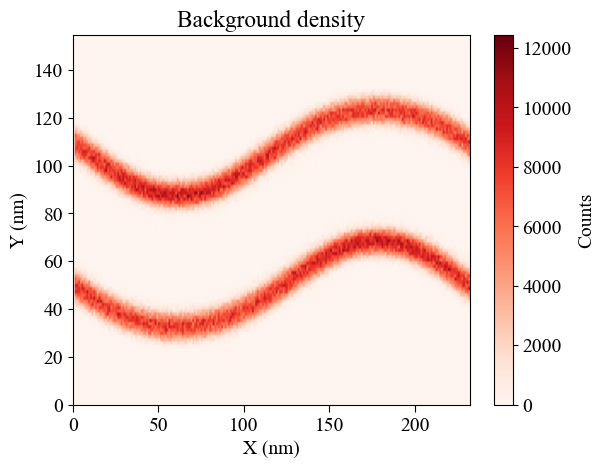

In [8]:
# Background density map
data_BG = load_dat(densmapBG)
trj_idxs, boxsizes = load_CALM_dimensions(dim)
boxsize = boxsizes[0]

# Plotting
fig, ax = plt.subplots()
im = ax.imshow(data_BG.T, origin="lower", extent=(0, boxsize[0], 0, boxsize[1]), aspect="auto", cmap="Reds")#, norm=norm)
fig.colorbar(im, ax=ax, label="Counts")
ax.set_xlabel("X (nm)")
ax.set_ylabel("Y (nm)")
ax.set_title("Background density");

/home/danie/miniconda3/envs/Thesis_WSL/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


Loading Data from: /home/danie/erda/1wave_9010/output/rep1/densmapCDL.dat
Loading Data from: /home/danie/erda/1wave_9010/output/rep1/densmapPOPC.dat


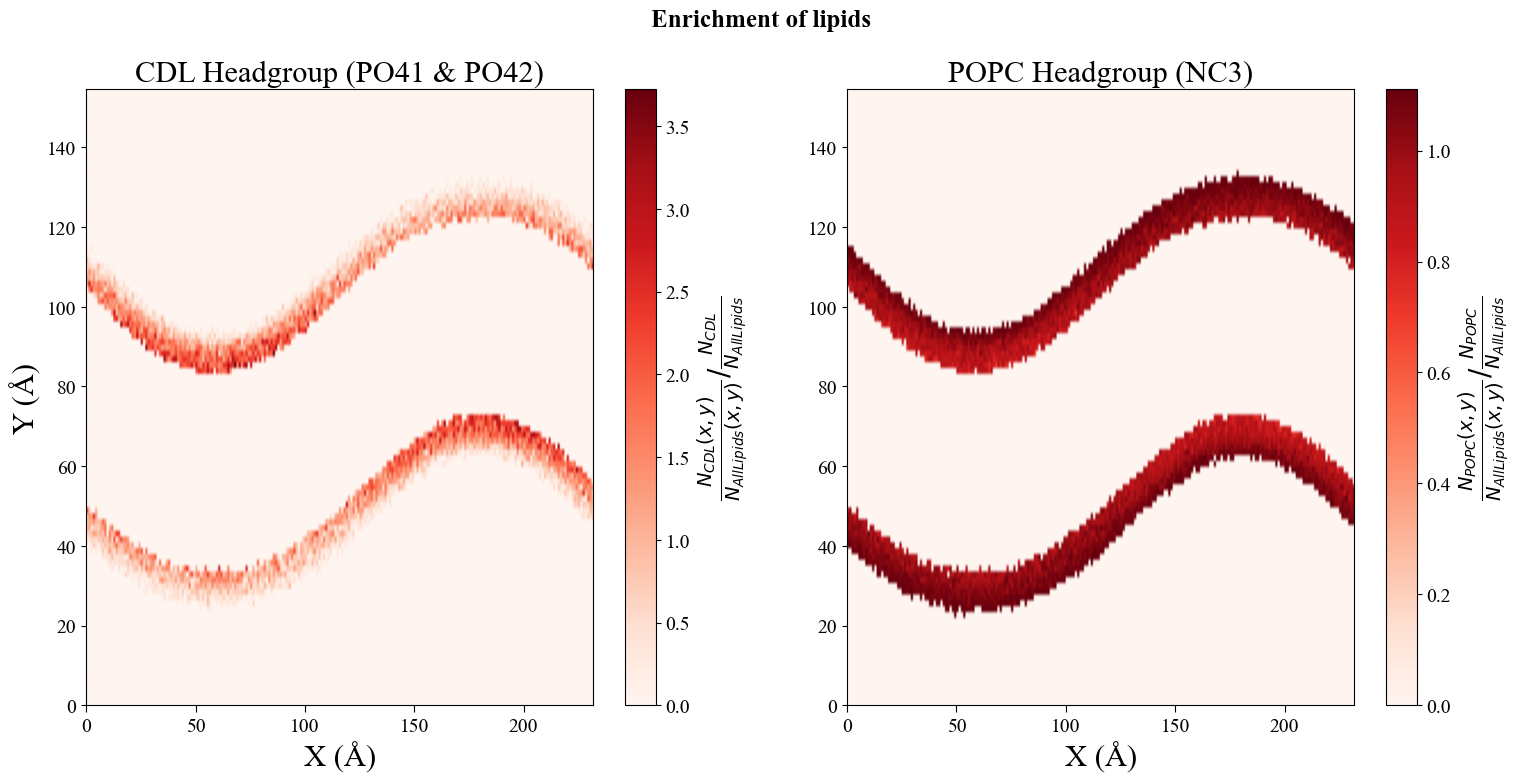

In [16]:
# Lipid density maps
files = [densmapCDL0, densmapPOPC]
titles = ["CDL Headgroup (PO41 & PO42)", "POPC Headgroup (NC3)"]
lipid_names = ["CDL", "POPC"]
threshold = 4000  # The threshold for which bins to use plot. Bins with fewer data points are not statistical reliable and will be set to 0

# Calculating fractions
system = load_mda_universe(pdb, xtc)
n_POPC = len(system.select_atoms(selections["NC3"]))
n_CDL = len(system.select_atoms(selections["PO4_1"]))
frac_POPC = n_POPC / (n_POPC + n_CDL)
frac_CDL = n_CDL / (n_POPC + n_CDL)
fractions = [frac_CDL, frac_POPC]


fig, ax = plt.subplots(1, 2, figsize=(18, 8))
ax = ax.flatten()
for i, file in enumerate(files):
    # Load and plot data
    data = load_dat(file, verbose=True)
    
    # Mask out the bins with too little data
    mask = data_BG > threshold
    E = np.zeros_like(data)
    
    # Calculate the enrichment, which is how much more likely we are to find the specific lipid relative to the expected amount
    E[mask] = (data[mask] / data_BG[mask]) / fractions[i]
    E[~mask] = 0

    # Plotting
    im = ax[i].imshow(E.T[5:-5, 5:-5], origin="lower", extent=(0, boxsize[0], 0, boxsize[1]), aspect="auto", cmap="Reds")#, norm=norm)
    # Other layout
    cbar = fig.colorbar(im, ax=ax[i])
    cbar.set_label(r"$\frac{N_{" + lipid_names[i] + r"}(x,y)}{N_{All Lipids}(x,y)} / \frac{N_{"+lipid_names[i]+"}}{N_{All Lipids}}$", fontsize=20)
    ax[i].set_xlabel("X (Å)", fontsize=22)
    if i == 0:
        ax[i].set_ylabel("Y (Å)", fontsize=22)
    ax[i].set_title(titles[i], fontsize=22)
fig.suptitle("Enrichment of lipids", fontsize=18);